## Objective
In this notebook we train and explore word embeddings on our insurance reviews dataset.
We will train our own Word2Vec model, use pre-trained GloVe embeddings, visualize
the embeddings, and implement similarity search using distance metrics.

## In this notebook we will:
- Train a Word2Vec model on our reviews
- Load and use pre-trained GloVe embeddings
- Visualize embeddings with Matplotlib and Tensorboard
- Implement Euclidean and cosine distance
- Build a semantic search function

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from gensim.models import Word2Vec
from nltk.corpus import stopwords
import nltk
import warnings
warnings.filterwarnings("ignore")

nltk.download("stopwords")
stop_fr = set(stopwords.words("french"))
df = pd.read_csv("topic_dataset.csv")

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/dovila/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [3]:
# Tokenize corrected French reviews
def tokenize(text):
    if pd.isna(text):
        return []
    tokens = str(text).lower().split()
    tokens = [t for t in tokens if t not in stop_fr and len(t) > 2 and t.isalpha()]
    return tokens

sentences = df['avis_cor'].apply(tokenize).tolist()
sentences = [s for s in sentences if len(s) > 0]

print(f"Total sentences: {len(sentences)}")

Total sentences: 34427


In [4]:
# Train Word2Vec model
model_w2v = Word2Vec(
    sentences=sentences,
    vector_size=100,    
    window=5,           
    min_count=5,        # ignore words appearing less than 5 times
    workers=4,         
    epochs=10,
    seed=42
)
print(f"Vocabulary size: {len(model_w2v.wv)}")

Vocabulary size: 9285


In [5]:
# Test similar words
test_words = ["assurance", "prix", "sinistre", "remboursement", "contrat"]

for word in test_words:
    if word in model_w2v.wv:
        similar = model_w2v.wv.most_similar(word, topn=5)
        print(f"\n Most similar to '{word}':")
        for w, score in similar:
            print(f"   {w}: {score:.4f}")


 Most similar to 'assurance':
   assurances: 0.5865
   compagnie: 0.4130
   issu: 0.3945
   adieu: 0.3793
   fortement: 0.3763

 Most similar to 'prix':
   tarif: 0.8639
   tarifs: 0.8296
   tarification: 0.6702
   marché: 0.6172
   relativement: 0.5845

 Most similar to 'sinistre':
   sinistres: 0.6967
   litige: 0.6888
   pépin: 0.6663
   accident: 0.6650
   incident: 0.6094

 Most similar to 'remboursement':
   remboursements: 0.6202
   règlement: 0.6038
   dentaires: 0.5844
   versement: 0.5788
   remboursés: 0.5694

 Most similar to 'contrat':
   contrats: 0.6106
   électroniquement: 0.5270
   électronique: 0.5177
   loi: 0.4377
   aperçu: 0.4347


The model has  learned semantic relationships between words
in our insurance reviews. For example, *prix* is closely related with *tarif*
and *tarification*, while *sinistre* is linked to *accident* and *incident*.
These results confirm that the model has captured meaningful knowledge from the corpus, which will be useful for our supervised learning and semantic search tasks.

## Part 2 — Embedding Visualization with Matplotlib
We reduce the high-dimensional word vectors to 2D using **t-SNE** so we can
visualize clusters of semantically similar words.

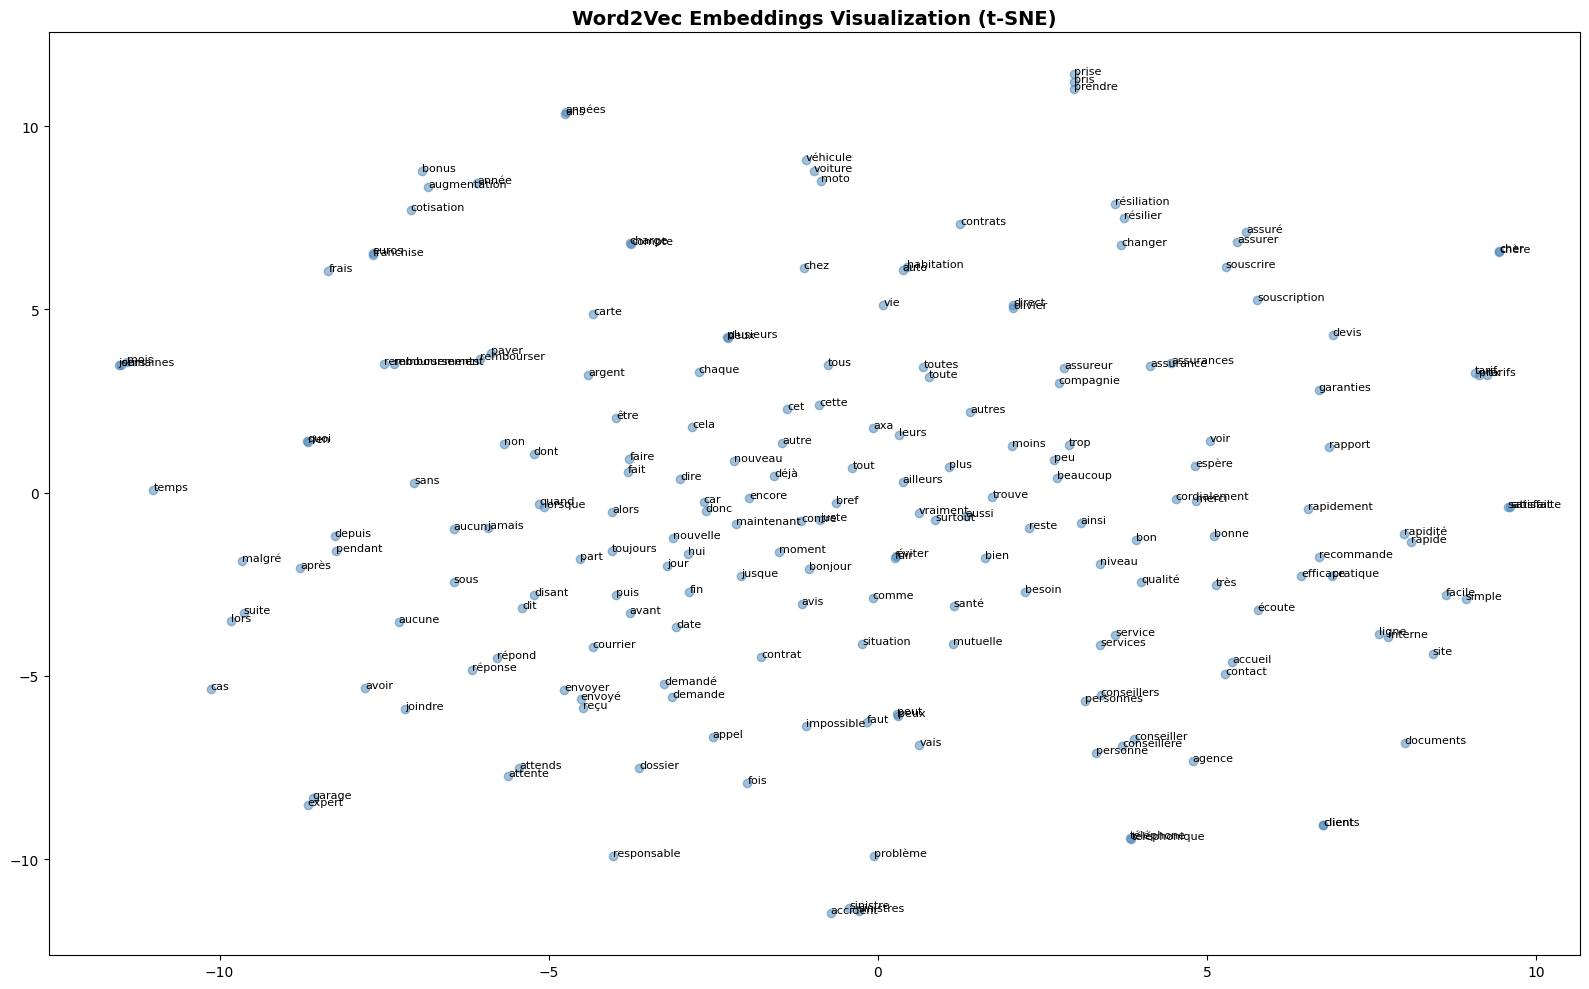

In [6]:
from sklearn.manifold import TSNE

# Select most frequent words for visualization
words = list(model_w2v.wv.index_to_key[:200])
vectors = np.array([model_w2v.wv[w] for w in words])

# Reduce to 2D with t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
vectors_2d = tsne.fit_transform(vectors)

# Plot
plt.figure(figsize=(16, 10))
plt.scatter(vectors_2d[:, 0], vectors_2d[:, 1], alpha=0.5, color='steelblue')

for i, word in enumerate(words):
    plt.annotate(word, (vectors_2d[i, 0], vectors_2d[i, 1]), fontsize=8)

plt.title("Word2Vec Embeddings Visualization (t-SNE)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

The t-SNE visualization reveals meaningful clusters of semantically related words.
For example, words related to vehicles (*véhicule, voiture, moto*) cluster together
in the top center, while contract-related terms (*résiliation, résilier, contrats*)
appear nearby. Customer service words (*téléphone, conseiller, agence*) form a
cluster on the right, and negative experience words (*malgré, aucune, attente*)
group together on the left. This confirms that our Word2Vec model has successfully
captured semantic relationships from the insurance reviews.

## Part 3 — Euclidean & Cosine Distance
To measure similarity between words, we implement two distance metrics:
- **Cosine similarity**: measures the angle between two vectors — the most
  commonly used metric for word embeddings
- **Euclidean distance**: measures the straight-line distance between two vectors

In [7]:
from numpy.linalg import norm

def cosine_similarity(w1, w2):
    v1 = model_w2v.wv[w1]
    v2 = model_w2v.wv[w2]
    return np.dot(v1, v2) / (norm(v1) * norm(v2))

def euclidean_distance(w1, w2):
    v1 = model_w2v.wv[w1]
    v2 = model_w2v.wv[w2]
    return norm(v1 - v2)

# Test with word pairs
word_pairs = [
    ("prix", "tarif"),
    ("sinistre", "accident"),
    ("remboursement", "paiement"),
    ("assurance", "mutuelle"),
    ("prix", "voiture")
]

print(f"{'Word Pair':<35} {'Cosine Similarity':>20} {'Euclidean Distance':>20}")
print("-" * 75)
for w1, w2 in word_pairs:
    if w1 in model_w2v.wv and w2 in model_w2v.wv:
        cos = cosine_similarity(w1, w2)
        euc = euclidean_distance(w1, w2)
        print(f"({w1}, {w2}):{'':<{30 - len(w1) - len(w2)}} {cos:>20.4f} {euc:>20.4f}")

Word Pair                              Cosine Similarity   Euclidean Distance
---------------------------------------------------------------------------
(prix, tarif):                                    0.8639               7.5064
(sinistre, accident):                             0.6650              12.0812
(remboursement, paiement):                        0.5139              11.6097
(assurance, mutuelle):                            0.3008              16.7291
(prix, voiture):                                  0.0346              20.1136


The distance metrics confirm the semantic relationships learned by our Word2Vec model.
*prix* and *tarif* have the highest cosine similarity (0.86) and lowest Euclidean
distance (7.51), confirming they are nearly synonymous in this context. *sinistre*
and *accident* are also closely related (0.67), as expected in insurance reviews.
As a sanity check, *prix* and *voiture* have a very low cosine similarity (0.03)
and high Euclidean distance (20.11), confirming they are semantically unrelated.
This validates that our embeddings have successfully captured meaningful word
relationships from the corpus.

***Bonus***

Semantic search

In [8]:
# Represent each review as the average of its word vectors
def get_review_vector(text):
    if pd.isna(text):
        return np.zeros(100)
    tokens = [t for t in str(text).lower().split() 
              if t in model_w2v.wv and t not in stop_fr]
    if not tokens:
        return np.zeros(100)
    return np.mean([model_w2v.wv[t] for t in tokens], axis=0)
review_vectors = np.array(df['avis_cor'].apply(get_review_vector).tolist())
print(f"Shape: {review_vectors.shape}")

Shape: (34427, 100)


In [9]:
# Semantic search function
def semantic_search(query, top_k=5):
    query_tokens = [t for t in query.lower().split() 
                    if t in model_w2v.wv and t not in stop_fr]
    
    if not query_tokens:
        print("No known words in query!")
        return
    
    query_vector = np.mean([model_w2v.wv[t] for t in query_tokens], axis=0)
    
    # Compute cosine similarity with all reviews
    similarities = []
    for i, vec in enumerate(review_vectors):
        if norm(vec) == 0:
            similarities.append(0)
        else:
            sim = np.dot(query_vector, vec) / (norm(query_vector) * norm(vec))
            similarities.append(sim)
    
    # Get top k results
    top_indices = np.argsort(similarities)[::-1][:top_k]
    
    print(f"\n Top {top_k} results for query: '{query}'\n")
    for rank, idx in enumerate(top_indices, 1):
        print(f"#{rank} (similarity: {similarities[idx]:.4f})")
        print(f"   {df['avis'].iloc[idx][:150]}...")
        print()

# Test semantic search
semantic_search("remboursement lent et difficile")


 Top 5 results for query: 'remboursement lent et difficile'

#1 (similarity: 0.7306)
   mauvais remboursement...

#2 (similarity: 0.6785)
   Je déconseille cette mutuelle:
impossible de les joindre
délai de remboursement très très long, au delà de 4 mois
aucune notification de remboursement...

#3 (similarity: 0.6720)
   N'importe laquelle sauf celle là. 
Impossible de faire machine arrière. Les délais sont très long pour un remboursement partiel. Explications foireuse...

#4 (similarity: 0.6608)
   Gros  problèmes  de  remboursement.  Ne  répond  pas  ou  répond  à  côté  du  sujet. Ne fournit pas de  relevé  mensuel papier.  Je  suis  très  méco...

#5 (similarity: 0.6601)
   Aucune visibilité sur la bonne réception de feuilles de soins. Des réponses tardives et évasives à des mails dans lesquels je demande ce quil en est d...



The semantic search works really well! Searching for *"remboursement lent et difficile"*
returns reviews about slow reimbursements and long delays, even without exact keyword matches.
This shows that our embeddings understand meaning, not just words  which will be very
useful for our Streamlit search application.

## Part 5 — GloVe Embeddings
GloVe (Global Vectors for Word Representation) is a pre-trained embedding model
developed by Stanford. Unlike Word2Vec which we trained from scratch on our dataset,
GloVe is trained on massive text corpora (billions of words) and captures much broader
semantic knowledge. We use the English GloVe vectors on our English reviews.

In [10]:
import gensim.downloader as api

print("Downloading GloVe embeddings...")
glove_model = api.load("glove-wiki-gigaword-100")
print(f"Vocabulary size: {len(glove_model)}")

[==================================================] 100.0% 128.1/128.1MB downloaded
Vocabulary size: 400000


In [12]:
# Test GloVe with insurance related words
test_words_en = ["insurance", "price", "claim", "reimbursement", "contract"]

for word in test_words_en:
    if word in glove_model:
        similar = glove_model.most_similar(word, topn=5)
        print(f"\n Most similar to '{word}':")
        for w, score in similar:
            print(f"   {w}: {score:.4f}")


 Most similar to 'insurance':
   insurers: 0.8099
   pension: 0.7752
   premiums: 0.7553
   care: 0.7154
   insurer: 0.7120

 Most similar to 'price':
   prices: 0.8555
   value: 0.7607
   drop: 0.7485
   stock: 0.7451
   market: 0.7408

 Most similar to 'claim':
   claims: 0.8713
   claiming: 0.8587
   claimed: 0.7871
   deny: 0.7398
   denied: 0.7103

 Most similar to 'reimbursement':
   reimbursements: 0.8419
   medicaid: 0.7579
   premiums: 0.7382
   payments: 0.7074
   expenses: 0.6906

 Most similar to 'contract':
   contracts: 0.8006
   deal: 0.7913
   signed: 0.7303
   agreement: 0.7145
   signing: 0.6951


In [13]:
# Compare Word2Vec vs GloVe on similar word pairs
word_pairs_en = [
    ("insurance", "coverage"),
    ("claim", "accident"),
    ("price", "cost"),
    ("contract", "policy"),
    ("price", "car")
]

print(f"{'Word Pair':<35} {'GloVe Cosine':>15} {'GloVe Euclidean':>18}")
print("-" * 70)
for w1, w2 in word_pairs_en:
    if w1 in glove_model and w2 in glove_model:
        v1, v2 = glove_model[w1], glove_model[w2]
        cos = np.dot(v1, v2) / (norm(v1) * norm(v2))
        euc = norm(v1 - v2)
        print(f"({w1}, {w2}):{'':<{30 - len(w1) - len(w2)}} {cos:>15.4f} {euc:>18.4f}")

Word Pair                              GloVe Cosine    GloVe Euclidean
----------------------------------------------------------------------
(insurance, coverage):                       0.6249             5.0578
(claim, accident):                           0.3555             6.2460
(price, cost):                               0.7253             4.3513
(contract, policy):                          0.3516             6.7396
(price, car):                                0.4482             6.5013


GloVe gives solid results on general English vocabulary. *price* and *cost* are
the closest pair (0.73), which makes sense. However our Word2Vec model trained
on insurance reviews is better for domain-specific terms since GloVe was trained
on general web text and doesn't capture insurance-specific language as well.

***Tensorboard***

We export our Word2Vec embeddings and visualize them
using the TensorBoard Embedding Projector.

In [19]:
import subprocess
subprocess.run(["pip", "install", "tensorboard"])
import os
os.makedirs("tensorboard_logs", exist_ok=True)

# Select top 500 words
words_tb = list(model_w2v.wv.index_to_key[:500])
vectors_tb = np.array([model_w2v.wv[w] for w in words_tb])

# Save vectors and metadata as TSV
np.savetxt("tensorboard_logs/vectors.tsv", vectors_tb, delimiter="\t")

with open("tensorboard_logs/metadata.tsv", "w", encoding="utf-8") as f:
    for word in words_tb:
        f.write(word + "\n")

print("Files saved in tensorboard_logs/")
print("vectors.tsv and metadata.tsv are ready!")

Files saved in tensorboard_logs/
vectors.tsv and metadata.tsv are ready!



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [18]:
from tensorboard.plugins import projector
import tensorflow as tf

log_dir = "tensorboard_logs"

# Create embedding variable
embedding_var = tf.Variable(vectors_tb, name="word_embeddings")

# Save checkpoint
checkpoint = tf.train.Checkpoint(embedding=embedding_var)
checkpoint.save(os.path.join(log_dir, "embedding.ckpt"))

# Configure projector
config = projector.ProjectorConfig()
embedding = config.embeddings.add()
embedding.tensor_name = "embedding/.ATTRIBUTES/VARIABLE_VALUE"
embedding.metadata_path = "metadata.tsv"
projector.visualize_embeddings(log_dir, config)

In [20]:
# Save Word2Vec model
model_w2v.save("word2vec_insurance.model")
print("Word2Vec model saved")

# Save review vectors for semantic search
np.save("review_vectors.npy", review_vectors)
print("Review vectors saved")

Word2Vec model saved
Review vectors saved
